In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedGroupKFold

# Locate the project root
current_folder = Path.cwd()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

# Load the processed diabetes dataset
processed_path = (
    project_root
    / "data"
    / "processed"
    / "diabetes_binary_clean.csv"
)

df = pd.read_csv(processed_path)

# Separate input features from the target
target_column = "Diabetes_binary"

X = df.drop(columns=[target_column])
y = df[target_column].astype("int8")

# Create a group identifier for every unique feature profile
profile_groups = pd.util.hash_pandas_object(
    X,
    index=False
).astype(str)

# Create an approximately 80% training and 20% testing split
splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, test_indices = next(
    splitter.split(
        X,
        y,
        groups=profile_groups
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

train_groups = set(profile_groups.iloc[train_indices])
test_groups = set(profile_groups.iloc[test_indices])

# Confirm that no identical feature profile appears in both partitions
assert train_groups.isdisjoint(test_groups)

print("Full dataset shape:", df.shape)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_string()
)

print("\nTesting target distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_string()
)

print(
    "\nOverlapping feature profiles:",
    len(train_groups.intersection(test_groups))
)

Full dataset shape: (253680, 22)
Training features shape: (202943, 21)
Testing features shape: (50737, 21)

Training target distribution:
Diabetes_binary
0    86.07
1    13.93

Testing target distribution:
Diabetes_binary
0    86.07
1    13.93

Overlapping feature profiles: 0


In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Define a reusable evaluation function
def evaluate_binary_model(
    model_name,
    true_labels,
    predicted_labels,
    positive_scores
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            true_labels,
            predicted_labels
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            true_labels,
            predicted_labels
        ),
        "Precision": precision_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "F1 Score": f1_score(
            true_labels,
            predicted_labels,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            true_labels,
            positive_scores
        ),
        "PR-AUC": average_precision_score(
            true_labels,
            positive_scores
        )
    }

# Train a baseline that always predicts the majority class
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(X_test)

baseline_scores = baseline_model.predict_proba(
    X_test
)[:, 1]

baseline_results = evaluate_binary_model(
    "Majority Class Baseline",
    y_test,
    baseline_predictions,
    baseline_scores
)

display(
    pd.DataFrame([baseline_results])
    .set_index("Model")
    .round(4)
)

print("Baseline confusion matrix:")
print(
    confusion_matrix(
        y_test,
        baseline_predictions
    )
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Model,,,,,,,
Majority Class Baseline,0.8607,0.5,0.0,0.0,0.0,0.5,0.1393


Baseline confusion matrix:
[[43667     0]
 [ 7070     0]]


In [3]:
# Preserve the profile groups that belong to the training partition
training_profile_groups = (
    profile_groups
    .iloc[train_indices]
    .reset_index(drop=True)
)

# Create a development and validation split
validation_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

development_positions, validation_positions = next(
    validation_splitter.split(
        X_train,
        y_train,
        groups=training_profile_groups
    )
)

X_development = X_train.iloc[
    development_positions
].copy()

X_validation = X_train.iloc[
    validation_positions
].copy()

y_development = y_train.iloc[
    development_positions
].copy()

y_validation = y_train.iloc[
    validation_positions
].copy()

development_groups = set(
    training_profile_groups.iloc[
        development_positions
    ]
)

validation_groups = set(
    training_profile_groups.iloc[
        validation_positions
    ]
)

# Confirm that identical profiles do not cross the split
assert development_groups.isdisjoint(
    validation_groups
)

print(
    "Development shape:",
    X_development.shape
)

print(
    "Validation shape:",
    X_validation.shape
)

print("\nDevelopment target distribution:")
print(
    y_development
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_string()
)

print("\nValidation target distribution:")
print(
    y_validation
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_string()
)

print(
    "\nOverlapping development and validation profiles:",
    len(
        development_groups.intersection(
            validation_groups
        )
    )
)

Development shape: (162354, 21)
Validation shape: (40589, 21)

Development target distribution:
Diabetes_binary
0    86.07
1    13.93

Validation target distribution:
Diabetes_binary
0    86.07
1    13.93

Overlapping development and validation profiles: 0


In [4]:
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a validation baseline for fair model comparison
validation_baseline = DummyClassifier(
    strategy="most_frequent"
)

validation_baseline.fit(
    X_development,
    y_development
)

validation_baseline_predictions = (
    validation_baseline.predict(
        X_validation
    )
)

validation_baseline_scores = (
    validation_baseline.predict_proba(
        X_validation
    )[:, 1]
)

validation_results = [
    evaluate_binary_model(
        "Majority Class Baseline",
        y_validation,
        validation_baseline_predictions,
        validation_baseline_scores
    )
]

# Create a pipeline that scales the features before classification
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

# Train

In [5]:
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a validation baseline for fair model comparison
validation_baseline = DummyClassifier(
    strategy="most_frequent"
)

validation_baseline.fit(
    X_development,
    y_development
)

validation_baseline_predictions = (
    validation_baseline.predict(X_validation)
)

validation_baseline_scores = (
    validation_baseline.predict_proba(
        X_validation
    )[:, 1]
)

validation_results = [
    evaluate_binary_model(
        "Majority Class Baseline",
        y_validation,
        validation_baseline_predictions,
        validation_baseline_scores
    )
]

# Build a pipeline that scales the features before classification
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

# Train the logistic regression model
training_start = perf_counter()

logistic_model.fit(
    X_development,
    y_development
)

logistic_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and scores
logistic_predictions = logistic_model.predict(
    X_validation
)

logistic_scores = logistic_model.predict_proba(
    X_validation
)[:, 1]

logistic_results = evaluate_binary_model(
    "Logistic Regression",
    y_validation,
    logistic_predictions,
    logistic_scores
)

logistic_results["Training Time (s)"] = (
    logistic_training_time
)

validation_results.append(logistic_results)

display(
    pd.DataFrame(validation_results)
    .set_index("Model")
    .round(4)
)

print(
    "Logistic regression confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        logistic_predictions
    )
)

print(
    "\nTraining time:",
    round(logistic_training_time, 2),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.8607,0.5000,0.0000,0.0000,0.0000,0.5000,0.1393,NaN
Logistic Regression,0.7260,0.7435,0.3068,0.7676,0.4384,0.8207,0.3959,1.1351


Logistic regression confusion matrix:
[[25127  9807]
 [ 1314  4341]]

Training time: 1.14 seconds


In [6]:
from sklearn.ensemble import RandomForestClassifier

# Build the random forest model
random_forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=16,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# Train the random forest model
training_start = perf_counter()

random_forest_model.fit(
    X_development,
    y_development
)

random_forest_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and scores
random_forest_predictions = (
    random_forest_model.predict(
        X_validation
    )
)

random_forest_scores = (
    random_forest_model.predict_proba(
        X_validation
    )[:, 1]
)

random_forest_results = evaluate_binary_model(
    "Random Forest",
    y_validation,
    random_forest_predictions,
    random_forest_scores
)

random_forest_results["Training Time (s)"] = (
    random_forest_training_time
)

validation_results.append(
    random_forest_results
)

display(
    pd.DataFrame(validation_results)
    .set_index("Model")
    .round(4)
)

print(
    "Random forest confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        random_forest_predictions
    )
)

print(
    "\nTraining time:",
    round(random_forest_training_time, 2),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.8607,0.5000,0.0000,0.0000,0.0000,0.5000,0.1393,NaN
Logistic Regression,0.7260,0.7435,0.3068,0.7676,0.4384,0.8207,0.3959,1.1351
Random Forest,0.7719,0.7361,0.3415,0.6865,0.4561,0.8238,0.4206,25.5679


Random forest confusion matrix:
[[27448  7486]
 [ 1773  3882]]

Training time: 25.57 seconds


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Build the histogram gradient boosting model
hist_gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

# Train the histogram gradient boosting model
training_start = perf_counter()

hist_gradient_boosting_model.fit(
    X_development,
    y_development
)

hist_gradient_boosting_training_time = (
    perf_counter() - training_start
)

# Generate validation predictions and probability scores
hist_gradient_boosting_predictions = (
    hist_gradient_boosting_model.predict(
        X_validation
    )
)

hist_gradient_boosting_scores = (
    hist_gradient_boosting_model.predict_proba(
        X_validation
    )[:, 1]
)

# Evaluate the model on the validation set
hist_gradient_boosting_results = evaluate_binary_model(
    "HistGradientBoosting",
    y_validation,
    hist_gradient_boosting_predictions,
    hist_gradient_boosting_scores
)

hist_gradient_boosting_results["Training Time (s)"] = (
    hist_gradient_boosting_training_time
)

validation_results.append(
    hist_gradient_boosting_results
)

# Display the updated model comparison
display(
    pd.DataFrame(validation_results)
    .set_index("Model")
    .round(4)
)

print(
    "HistGradientBoosting confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        hist_gradient_boosting_predictions
    )
)

print(
    "\nTraining time:",
    round(hist_gradient_boosting_training_time, 2),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Model,,,,,,,,
Majority Class Baseline,0.8607,0.5000,0.0000,0.0000,0.0000,0.5000,0.1393,NaN
Logistic Regression,0.7260,0.7435,0.3068,0.7676,0.4384,0.8207,0.3959,1.1351
Random Forest,0.7719,0.7361,0.3415,0.6865,0.4561,0.8238,0.4206,25.5679
HistGradientBoosting,0.7160,0.7498,0.3027,0.7966,0.4387,0.8279,0.4300,10.4470


HistGradientBoosting confusion matrix:
[[24555 10379]
 [ 1150  4505]]

Training time: 10.45 seconds


In [9]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall across all possible thresholds
threshold_precision, threshold_recall, decision_thresholds = (
    precision_recall_curve(
        y_validation,
        hist_gradient_boosting_scores
    )
)

# Remove the final precision and recall values
# because they do not have a corresponding threshold
threshold_results = pd.DataFrame(
    {
        "Threshold": decision_thresholds,
        "Precision": threshold_precision[:-1],
        "Recall": threshold_recall[:-1]
    }
)

# Calculate the F1 score for every threshold
threshold_results["F1 Score"] = (
    2
    * threshold_results["Precision"]
    * threshold_results["Recall"]
    / (
        threshold_results["Precision"]
        + threshold_results["Recall"]
        + 1e-10
    )
)

# Keep thresholds that achieve at least 75 percent recall
eligible_thresholds = threshold_results[
    threshold_results["Recall"] >= 0.75
].copy()

# Select the threshold with the highest precision
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["Precision"].idxmax()
]

selected_threshold = float(
    best_threshold_row["Threshold"]
)

# Generate predictions using the selected threshold
tuned_validation_predictions = (
    hist_gradient_boosting_scores
    >= selected_threshold
).astype(int)

tuned_validation_results = evaluate_binary_model(
    "HistGradientBoosting Tuned",
    y_validation,
    tuned_validation_predictions,
    hist_gradient_boosting_scores
)

tuned_validation_results["Threshold"] = (
    selected_threshold
)

# Display the selected threshold and its performance
print(
    "Selected decision threshold:",
    round(selected_threshold, 4)
)

display(
    pd.DataFrame(
        [tuned_validation_results]
    )
    .set_index("Model")
    .round(4)
)

print(
    "Tuned validation confusion matrix:"
)

print(
    confusion_matrix(
        y_validation,
        tuned_validation_predictions
    )
)

Selected decision threshold: 0.547


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
Model,,,,,,,,
HistGradientBoosting Tuned,0.7449,0.7471,0.3218,0.7503,0.4504,0.8279,0.43,0.547


Tuned validation confusion matrix:
[[25990  8944]
 [ 1412  4243]]


In [10]:
# Build the final diabetes model
final_diabetes_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

# Train the final model using the complete training set
final_training_start = perf_counter()

final_diabetes_model.fit(
    X_train,
    y_train
)

final_training_time = (
    perf_counter() - final_training_start
)

# Generate probability scores for the reserved test set
final_test_scores = (
    final_diabetes_model.predict_proba(
        X_test
    )[:, 1]
)

# Apply the threshold selected using validation data
final_test_predictions = (
    final_test_scores
    >= selected_threshold
).astype(int)

# Evaluate the final model on the reserved test set
final_test_results = evaluate_binary_model(
    "Final HistGradientBoosting",
    y_test,
    final_test_predictions,
    final_test_scores
)

final_test_results["Threshold"] = (
    selected_threshold
)

final_test_results["Training Time (s)"] = (
    final_training_time
)

# Display the final test results
display(
    pd.DataFrame(
        [final_test_results]
    )
    .set_index("Model")
    .round(4)
)

print(
    "Final test confusion matrix:"
)

print(
    confusion_matrix(
        y_test,
        final_test_predictions
    )
)

print(
    "\nFinal training time:",
    round(final_training_time, 2),
    "seconds"
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold,Training Time (s)
Model,,,,,,,,,
Final HistGradientBoosting,0.751,0.7519,0.3284,0.753,0.4574,0.8313,0.4317,0.547,10.2904


Final test confusion matrix:
[[32780 10887]
 [ 1746  5324]]

Final training time: 10.29 seconds


In [11]:
from pathlib import Path
import joblib

# Locate the project root
current_folder = Path.cwd()

project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

# Create the models folder if it does not exist
models_folder = project_root / "models"
models_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Define the saved model path
model_path = (
    models_folder
    / "diabetes_model.joblib"
)

# Create a complete model package
diabetes_model_package = {
    "model": final_diabetes_model,
    "threshold": selected_threshold,
    "feature_names": X_train.columns.tolist(),
    "target_name": "Diabetes_binary",
    "model_name": "HistGradientBoostingClassifier",
    "dataset_name": (
        "CDC BRFSS 2015 Diabetes Health Indicators"
    ),
    "test_metrics": final_test_results
}

# Save the model package
joblib.dump(
    diabetes_model_package,
    model_path
)

# Load the package again to verify the saved file
loaded_model_package = joblib.load(
    model_path
)

# Verify the saved model using five test records
verification_scores = (
    loaded_model_package["model"]
    .predict_proba(
        X_test.iloc[:5]
    )[:, 1]
)

verification_predictions = (
    verification_scores
    >= loaded_model_package["threshold"]
).astype(int)

print(
    "Model saved successfully:",
    model_path.exists()
)

print(
    "Saved model path:",
    model_path
)

print(
    "Saved threshold:",
    loaded_model_package["threshold"]
)

print(
    "Number of saved features:",
    len(
        loaded_model_package[
            "feature_names"
        ]
    )
)

print(
    "Verification predictions:",
    verification_predictions
)

Model saved successfully: True
Saved model path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\diabetes_model.joblib
Saved threshold: 0.5469571860540241
Number of saved features: 21
Verification predictions: [0 0 0 0 0]


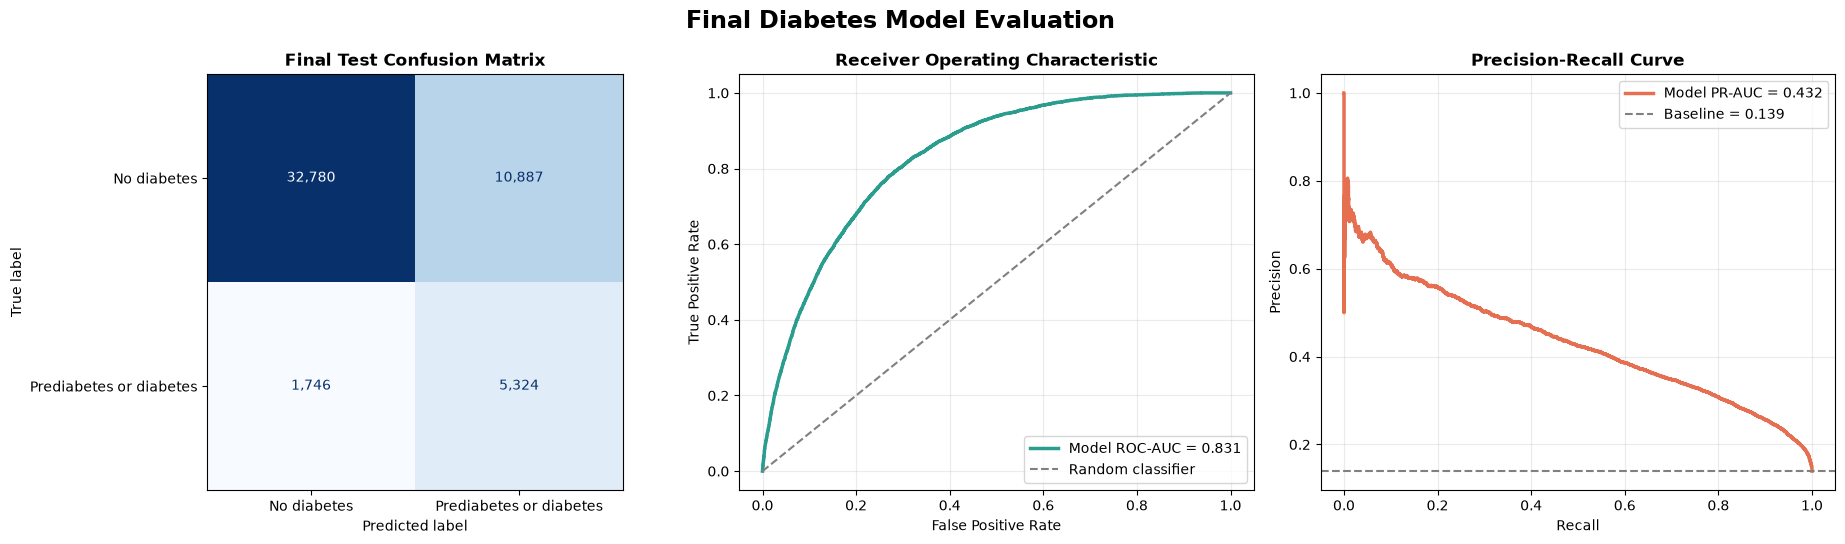

Evaluation figure saved: True
Evaluation figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\diabetes_final_model_evaluation.png


In [12]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# Create the reports figures folder
figures_folder = (
    project_root
    / "reports"
    / "figures"
)

figures_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Calculate the confusion matrix
final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions
)

# Calculate the ROC curve
false_positive_rate, true_positive_rate, _ = (
    roc_curve(
        y_test,
        final_test_scores
    )
)

roc_auc_value = auc(
    false_positive_rate,
    true_positive_rate
)

# Calculate the precision-recall curve
pr_precision, pr_recall, _ = (
    precision_recall_curve(
        y_test,
        final_test_scores
    )
)

pr_auc_value = auc(
    pr_recall,
    pr_precision
)

positive_class_rate = y_test.mean()

# Create the final evaluation figure
figure, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5.5)
)

# Plot the confusion matrix
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "No diabetes",
        "Prediabetes or diabetes"
    ]
)

confusion_display.plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format=",d"
)

axes[0].set_title(
    "Final Test Confusion Matrix",
    fontweight="bold"
)

# Plot the ROC curve
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    color="#2A9D8F",
    linewidth=2.5,
    label=f"Model ROC-AUC = {roc_auc_value:.3f}"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

axes[1].set_title(
    "Receiver Operating Characteristic",
    fontweight="bold"
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].legend(
    loc="lower right"
)

axes[1].grid(
    alpha=0.25
)

# Plot the precision-recall curve
axes[2].plot(
    pr_recall,
    pr_precision,
    color="#E76F51",
    linewidth=2.5,
    label=f"Model PR-AUC = {pr_auc_value:.3f}"
)

axes[2].axhline(
    positive_class_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline = {positive_class_rate:.3f}"
)

axes[2].set_title(
    "Precision-Recall Curve",
    fontweight="bold"
)

axes[2].set_xlabel(
    "Recall"
)

axes[2].set_ylabel(
    "Precision"
)

axes[2].legend(
    loc="upper right"
)

axes[2].grid(
    alpha=0.25
)

figure.suptitle(
    "Final Diabetes Model Evaluation",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

# Save the final evaluation figure
evaluation_figure_path = (
    figures_folder
    / "diabetes_final_model_evaluation.png"
)

plt.savefig(
    evaluation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Evaluation figure saved:",
    evaluation_figure_path.exists()
)

print(
    "Evaluation figure path:",
    evaluation_figure_path
)

,Feature,Importance,Standard Deviation
0,BMI,0.0877,0.0022
1,GenHlth,0.0739,0.0021
2,Age,0.0332,0.0006
3,HighBP,0.0313,0.0018
4,HighChol,0.0264,0.0011
5,HvyAlcoholConsump,0.0058,0.0014
6,CholCheck,0.0049,0.0004
7,HeartDiseaseorAttack,0.0040,0.0005
8,Sex,0.0040,0.0004
9,DiffWalk,0.0031,0.0008


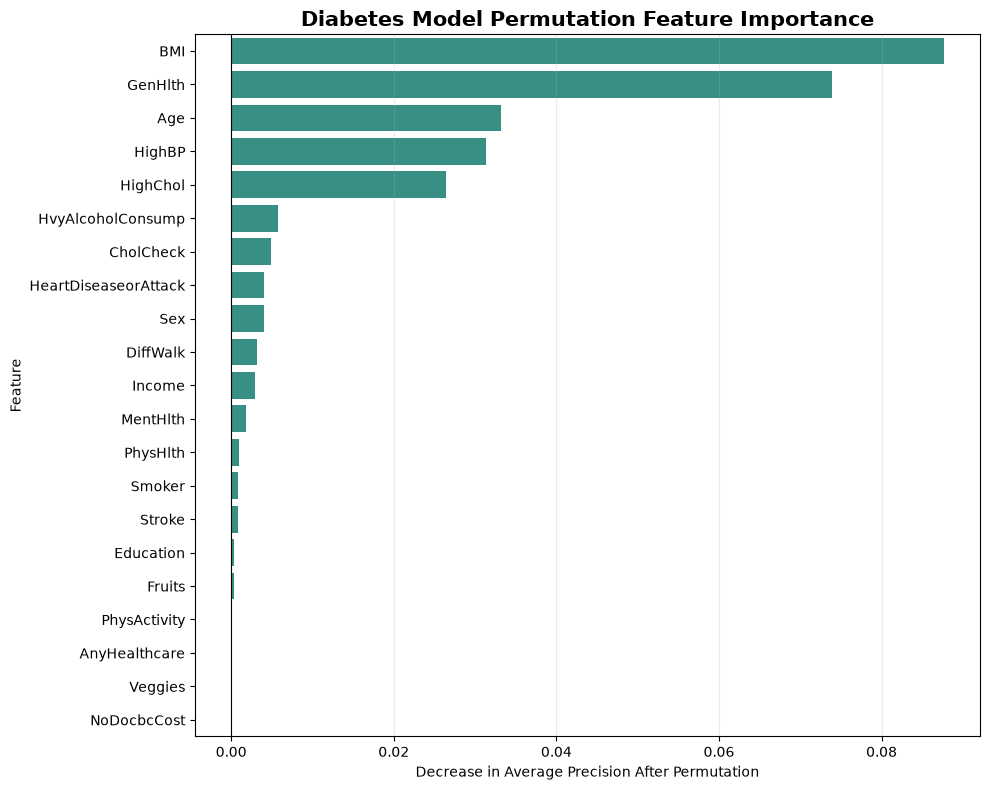

Feature importance figure saved: True
Feature importance figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\diabetes_feature_importance.png


In [13]:
from sklearn.inspection import permutation_importance

# Calculate feature importance using the reserved test set
permutation_results = permutation_importance(
    final_diabetes_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

# Create a feature importance table
feature_importance = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": (
            permutation_results.importances_mean
        ),
        "Standard Deviation": (
            permutation_results.importances_std
        )
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    feature_importance.round(4)
)

# Create the feature importance chart
plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color="#2A9D8F"
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Diabetes Model Permutation Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Decrease in Average Precision After Permutation"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

# Save the feature importance chart
feature_importance_path = (
    figures_folder
    / "diabetes_feature_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Feature importance figure saved:",
    feature_importance_path.exists()
)

print(
    "Feature importance figure path:",
    feature_importance_path
)